In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
# import scipy.io
from poisson_glm_granger import compute_granger_causality, compute_optimal_lags
# from joblib import Parallel, delayed
from statsmodels.stats.multitest import multipletests
import pickle

In [2]:
def add_subplot_label(ax, label, x=-.21, y=1.225):
    ax.text(x, y, label,  # Adjust left of y-axis
            transform=ax.transAxes,
            fontsize=26, va='top', ha='right')

In [3]:
conditions=['GO','SS','FS']

In [4]:
path = '/home/qmoreau/schmidt_data/output/'

# combine bursts_all_results and bursts_all_results_cue
bursts_all_results_laplac = np.load(f'{path}/bursts_all_results_laplac.npy', allow_pickle=True)

In [5]:
all_bursts={
    'trial': [],
    'waveform': [],
    'peak_freq': [],
    'peak_amp_iter': [],
    'peak_amp_base': [],
    'peak_time': [],
    'peak_adjustment': [],
    'fwhm_freq': [],
    'fwhm_time': [],
    'polarity': [],
    'waveform_times': [],
    'condition': [],
    'electrode': [],
    'subject': [],
    'experiment': [],
    'epochs': []
}
for bursts in bursts_all_results_laplac:
    for key in bursts:
        if not key=='waveform_times':
            all_bursts[key].extend(bursts[key])
        else:
            all_bursts[key]=bursts[key]
            
for key in all_bursts:
    all_bursts[key]=np.array(all_bursts[key])

In [6]:
c3_idx=(all_bursts['electrode']=='C3')
f4_idx=(all_bursts['electrode']=='F4')

In [7]:
# Load the fitted scaler and PCA objects
with open('robust_scaler_c3.pkl', 'rb') as scaler_file:
    scaler_laplac_C3 = pickle.load(scaler_file)

with open('pca_object_c3.pkl', 'rb') as pca_file:
    model_laplac_C3 = pickle.load(pca_file)
    
with open('robust_scaler_f4.pkl', 'rb') as scaler_file:
    scaler_laplac_F4 = pickle.load(scaler_file)

with open('pca_object_f4.pkl', 'rb') as pca_file:
    model_laplac_F4 = pickle.load(pca_file)

In [8]:
waveforms_laplac_C3=all_bursts['waveform'][c3_idx,:]
waveforms_laplac_C3_std = scaler_laplac_C3.transform(waveforms_laplac_C3)
model_laplac_C3.fit(waveforms_laplac_C3_std)
# Transforming the data to get principal components
pc_scores_laplac_C3 = model_laplac_C3.transform(waveforms_laplac_C3_std)  # all the bursts x 20 components
pc_labels_laplac_C3 = ["PC_{}".format(i + 1) for i in range(pc_scores_laplac_C3.shape[1])]

In [9]:
waveforms_laplac_F4=all_bursts['waveform'][f4_idx,:]
waveforms_laplac_F4_std = scaler_laplac_F4.transform(waveforms_laplac_F4)
model_laplac_F4.fit(waveforms_laplac_F4_std)
# Transforming the data to get principal components
pc_scores_laplac_F4 = model_laplac_F4.transform(waveforms_laplac_F4_std)  # all the bursts x 20 components
pc_labels_laplac_F4 = ["PC_{}".format(i + 1) for i in range(pc_scores_laplac_F4.shape[1])]

In [10]:
n_q=3
unit_labels=[]
region_labels=['C3','F4']
region_pcs={
    'C3': [2],
    'F4': [5]
}
for region in region_labels:
    for pc in region_pcs[region]:
        for q in range(n_q):
            unit_labels.append(f'{region}-PC{pc+1}-Q{q+1}')

In [11]:
unit_labels

['C3-PC3-Q1', 'C3-PC3-Q2', 'C3-PC3-Q3', 'F4-PC6-Q1', 'F4-PC6-Q2', 'F4-PC6-Q3']

In [12]:
step = 100 / n_q
time_bin_size = .01
#time_bins = np.arange(-1, 2 + time_bin_size, time_bin_size)
time_bins = np.arange(0, 0.75 + time_bin_size, time_bin_size)

subjects = np.unique(all_bursts['subject'])
print(subjects)
n_subjects = len(subjects)

['S1' 'S10' 'S11' 'S13' 'S14' 'S15' 'S2' 'S3' 'S5' 'S6' 'S7' 'S8']


In [13]:
all_binned_bursts=[]
for subject in subjects:
    subj_idx = (all_bursts['subject'] == subject)
    subject_binned_bursts={
        condition: [] for condition in conditions
    }
    for cond in conditions :
        cond_trials = np.unique(all_bursts['trial'][subj_idx & (all_bursts['condition']==cond)])
        cond_binned_bursts=[]
        for region in ['C3','F4']:
            for pc_idx in region_pcs[region]:
                if region=='C3':
                    q_bins = np.percentile(pc_scores_laplac_C3[:,pc_idx], np.arange(0,100+step,step))
                elif region=='F4':
                    q_bins = np.percentile(pc_scores_laplac_F4[:,pc_idx], np.arange(0,100+step,step))
                for q in range(n_q):
                    if region=='C3':
                        q_idx = (all_bursts['electrode']=='C3')
                        q_idx[np.where(q_idx)[0]] = (pc_scores_laplac_C3[:,pc_idx] >= q_bins[q]) & (pc_scores_laplac_C3[:,pc_idx] <= q_bins[q+1])    
                    elif region=='F4':
                        q_idx = (all_bursts['electrode']=='F4')
                        q_idx[np.where(q_idx)[0]] = (pc_scores_laplac_F4[:,pc_idx] >= q_bins[q]) & (pc_scores_laplac_F4[:,pc_idx] <= q_bins[q+1])
                    unit_bursts=[]
                    for trial in cond_trials:
                        b_idx = subj_idx & (all_bursts['condition']==cond) & q_idx & (all_bursts['trial']==trial) & (all_bursts['peak_time']>=time_bins[0]) & (all_bursts['peak_time']<=time_bins[-1])
                        binned_bursts, _ = np.histogram(all_bursts['peak_time'][b_idx], bins=time_bins)
                        unit_bursts.append(binned_bursts)
                    cond_binned_bursts.append(unit_bursts)
        subject_binned_bursts[cond]=np.array(cond_binned_bursts)
    all_binned_bursts.append(subject_binned_bursts)

In [14]:
optimal_lags={
    condition: [] for condition in conditions
}
gc_matrices={
    condition: [] for condition in conditions
}
signed_gc_matrices={
    condition: [] for condition in conditions
}
for s_idx, subject in enumerate(subjects):
    Xfs=all_binned_bursts[s_idx]['FS']
    Xss=all_binned_bursts[s_idx]['SS']
    X = np.concatenate((Xfs, Xss), axis=1)
    pairwise_lags = compute_optimal_lags(
        X,
        lags=np.arange(1,10),
        folds=10,
        n_jobs=10
    )
    for cond in gc_matrices:
        print(f'{subject} - {cond}')
        X=all_binned_bursts[s_idx][cond]

        optimal_lag, gc_matrix, signed_gc_matrix = compute_granger_causality(
            X,
            n_jobs=10,
            pairwise_lags=pairwise_lags
        )
        optimal_lags[cond].append(pairwise_lags)
        gc_matrices[cond].append(gc_matrix)
        signed_gc_matrices[cond].append(signed_gc_matrix)

S1 - GO
Data contains 6 neurons, 1063 trials, and 75 time steps.
S1 - SS
Data contains 6 neurons, 179 trials, and 75 time steps.
S1 - FS
Data contains 6 neurons, 195 trials, and 75 time steps.
S10 - GO
Data contains 6 neurons, 1187 trials, and 75 time steps.
S10 - SS
Data contains 6 neurons, 161 trials, and 75 time steps.
S10 - FS
Data contains 6 neurons, 175 trials, and 75 time steps.
S11 - GO
Data contains 6 neurons, 1050 trials, and 75 time steps.
S11 - SS
Data contains 6 neurons, 146 trials, and 75 time steps.
S11 - FS
Data contains 6 neurons, 149 trials, and 75 time steps.
S13 - GO
Data contains 6 neurons, 1114 trials, and 75 time steps.
S13 - SS
Data contains 6 neurons, 156 trials, and 75 time steps.
S13 - FS
Data contains 6 neurons, 164 trials, and 75 time steps.
S14 - GO
Data contains 6 neurons, 527 trials, and 75 time steps.
S14 - SS
Data contains 6 neurons, 142 trials, and 75 time steps.
S14 - FS
Data contains 6 neurons, 140 trials, and 75 time steps.
S15 - GO
Data contains 6

/home/qmoreau/miniconda3/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


S2 - GO
Data contains 6 neurons, 986 trials, and 75 time steps.
S2 - SS
Data contains 6 neurons, 173 trials, and 75 time steps.
S2 - FS
Data contains 6 neurons, 175 trials, and 75 time steps.
S3 - GO
Data contains 6 neurons, 563 trials, and 75 time steps.
S3 - SS
Data contains 6 neurons, 198 trials, and 75 time steps.
S3 - FS
Data contains 6 neurons, 202 trials, and 75 time steps.
S5 - GO
Data contains 6 neurons, 562 trials, and 75 time steps.
S5 - SS
Data contains 6 neurons, 199 trials, and 75 time steps.
S5 - FS
Data contains 6 neurons, 198 trials, and 75 time steps.
S6 - GO
Data contains 6 neurons, 577 trials, and 75 time steps.
S6 - SS
Data contains 6 neurons, 200 trials, and 75 time steps.
S6 - FS
Data contains 6 neurons, 202 trials, and 75 time steps.
S7 - GO
Data contains 6 neurons, 500 trials, and 75 time steps.
S7 - SS
Data contains 6 neurons, 159 trials, and 75 time steps.
S7 - FS
Data contains 6 neurons, 153 trials, and 75 time steps.
S8 - GO
Data contains 6 neurons, 564 tri

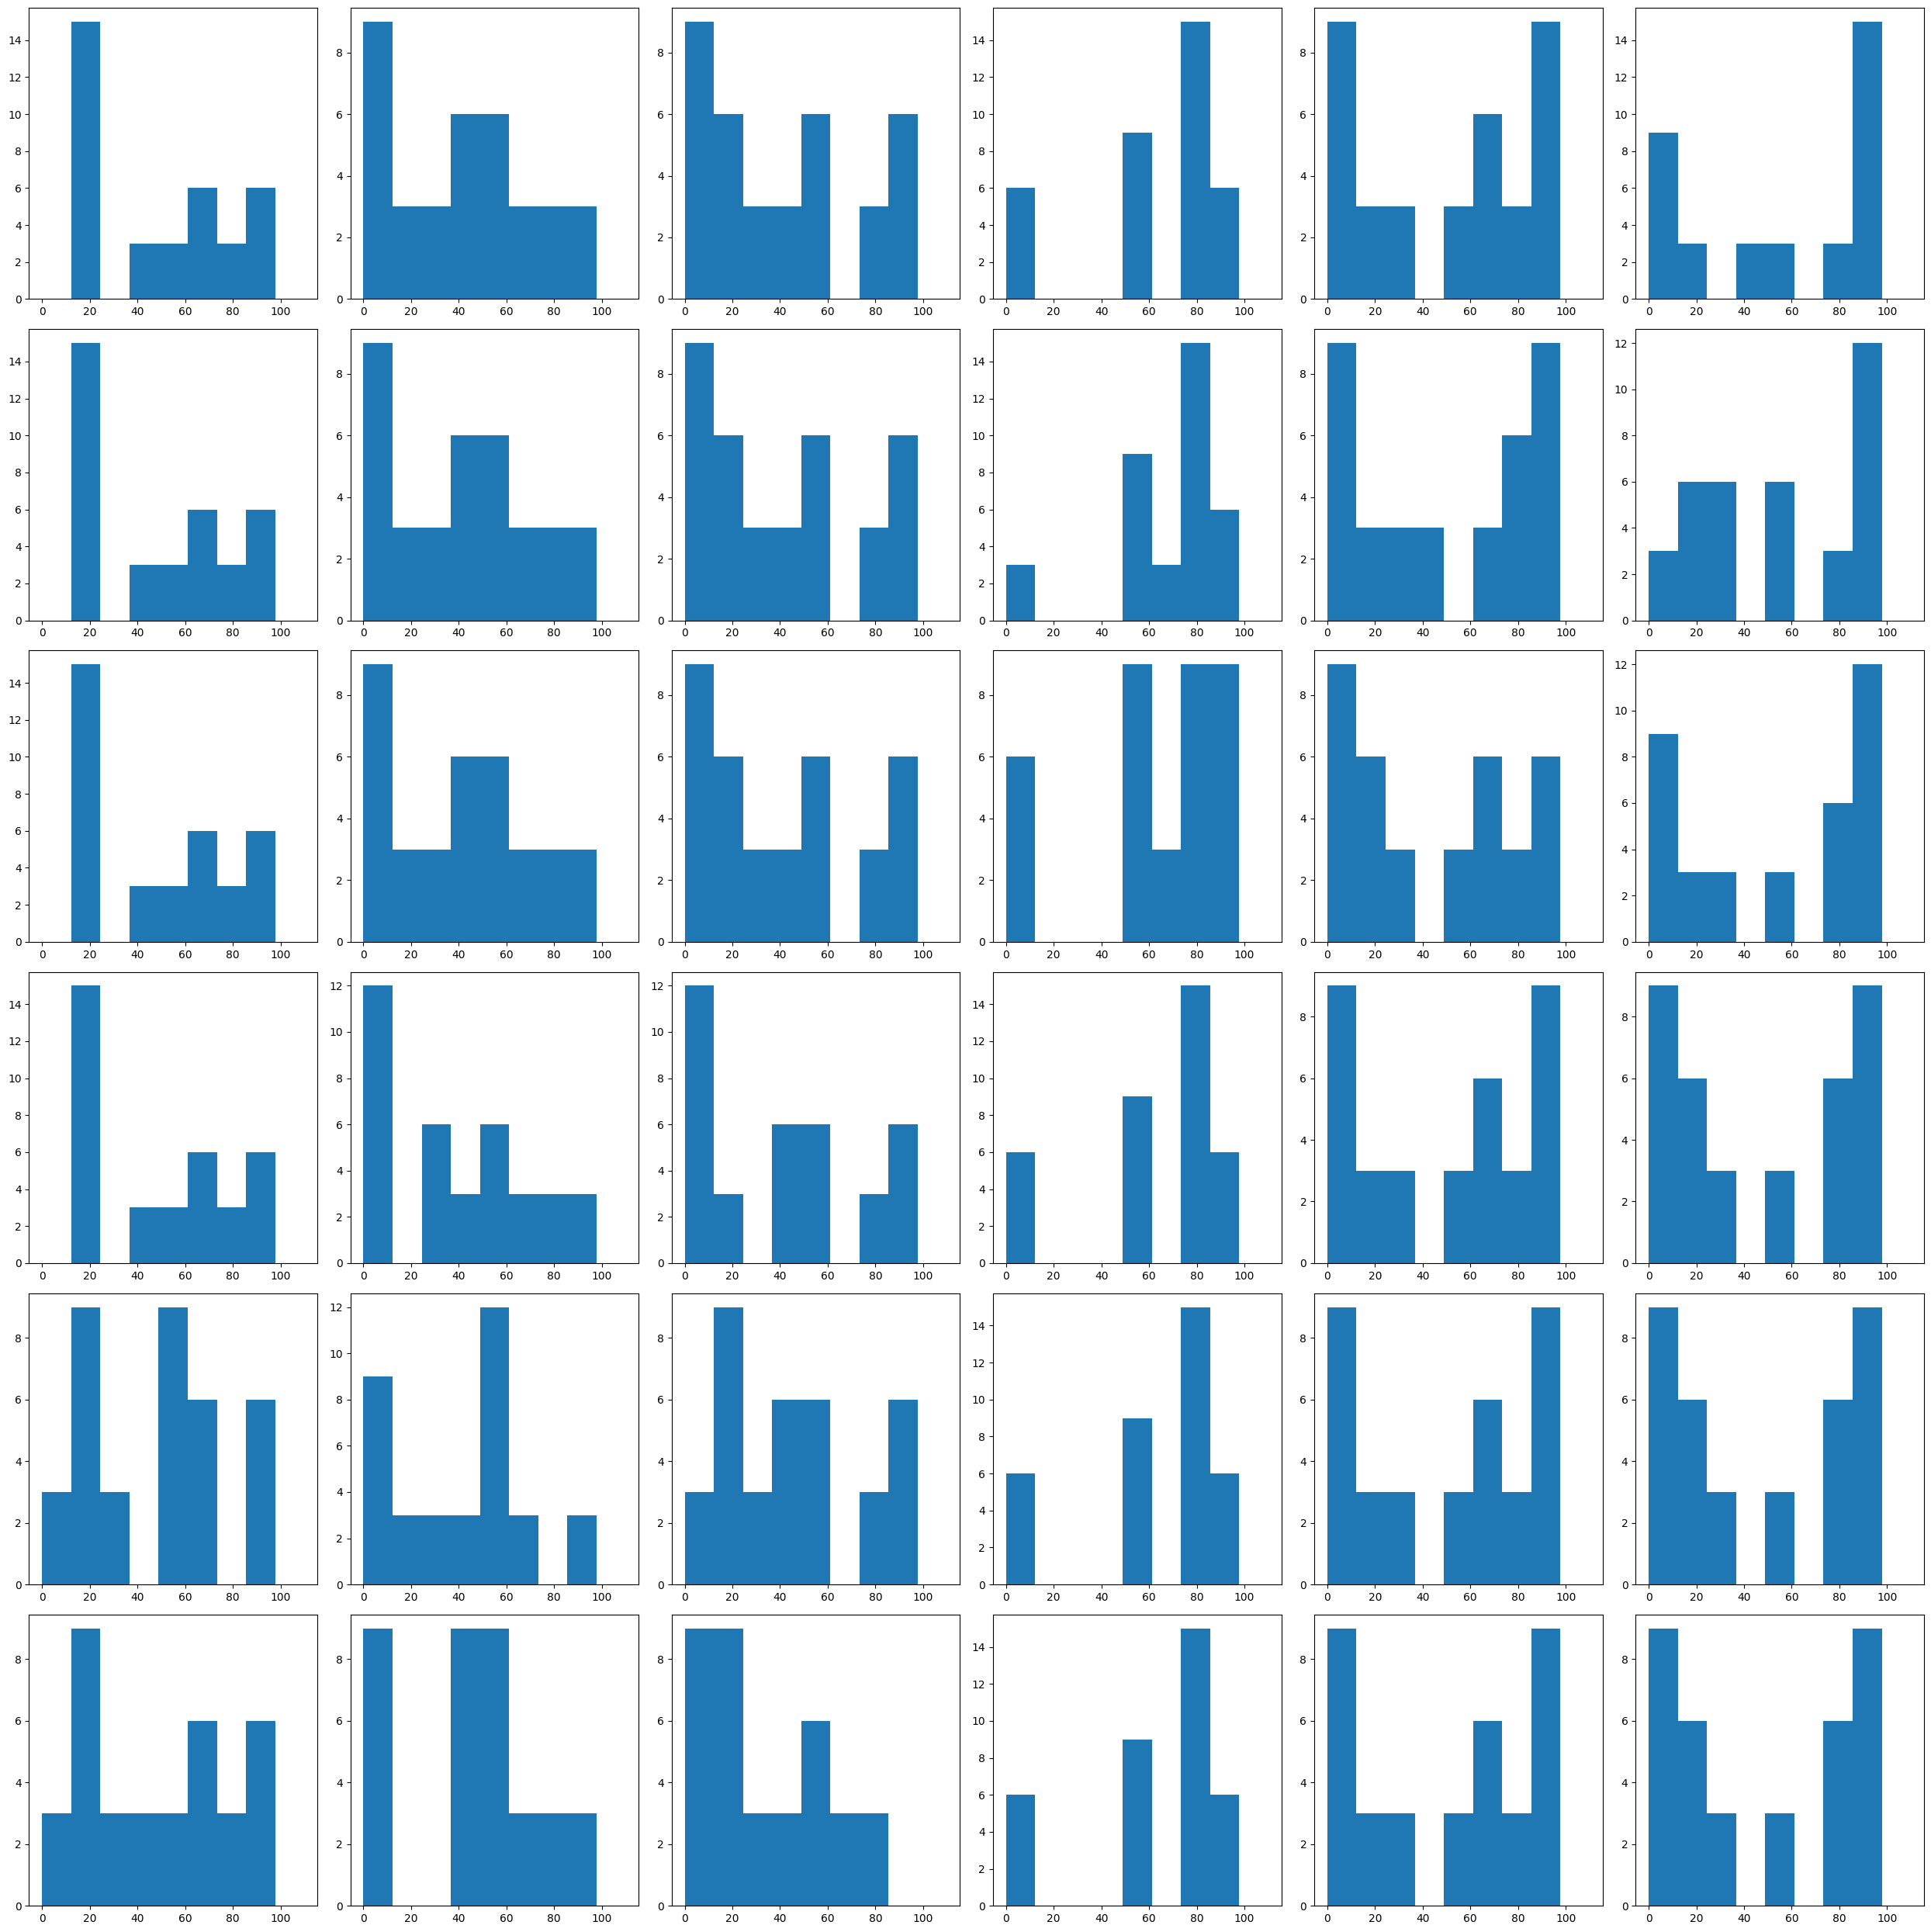

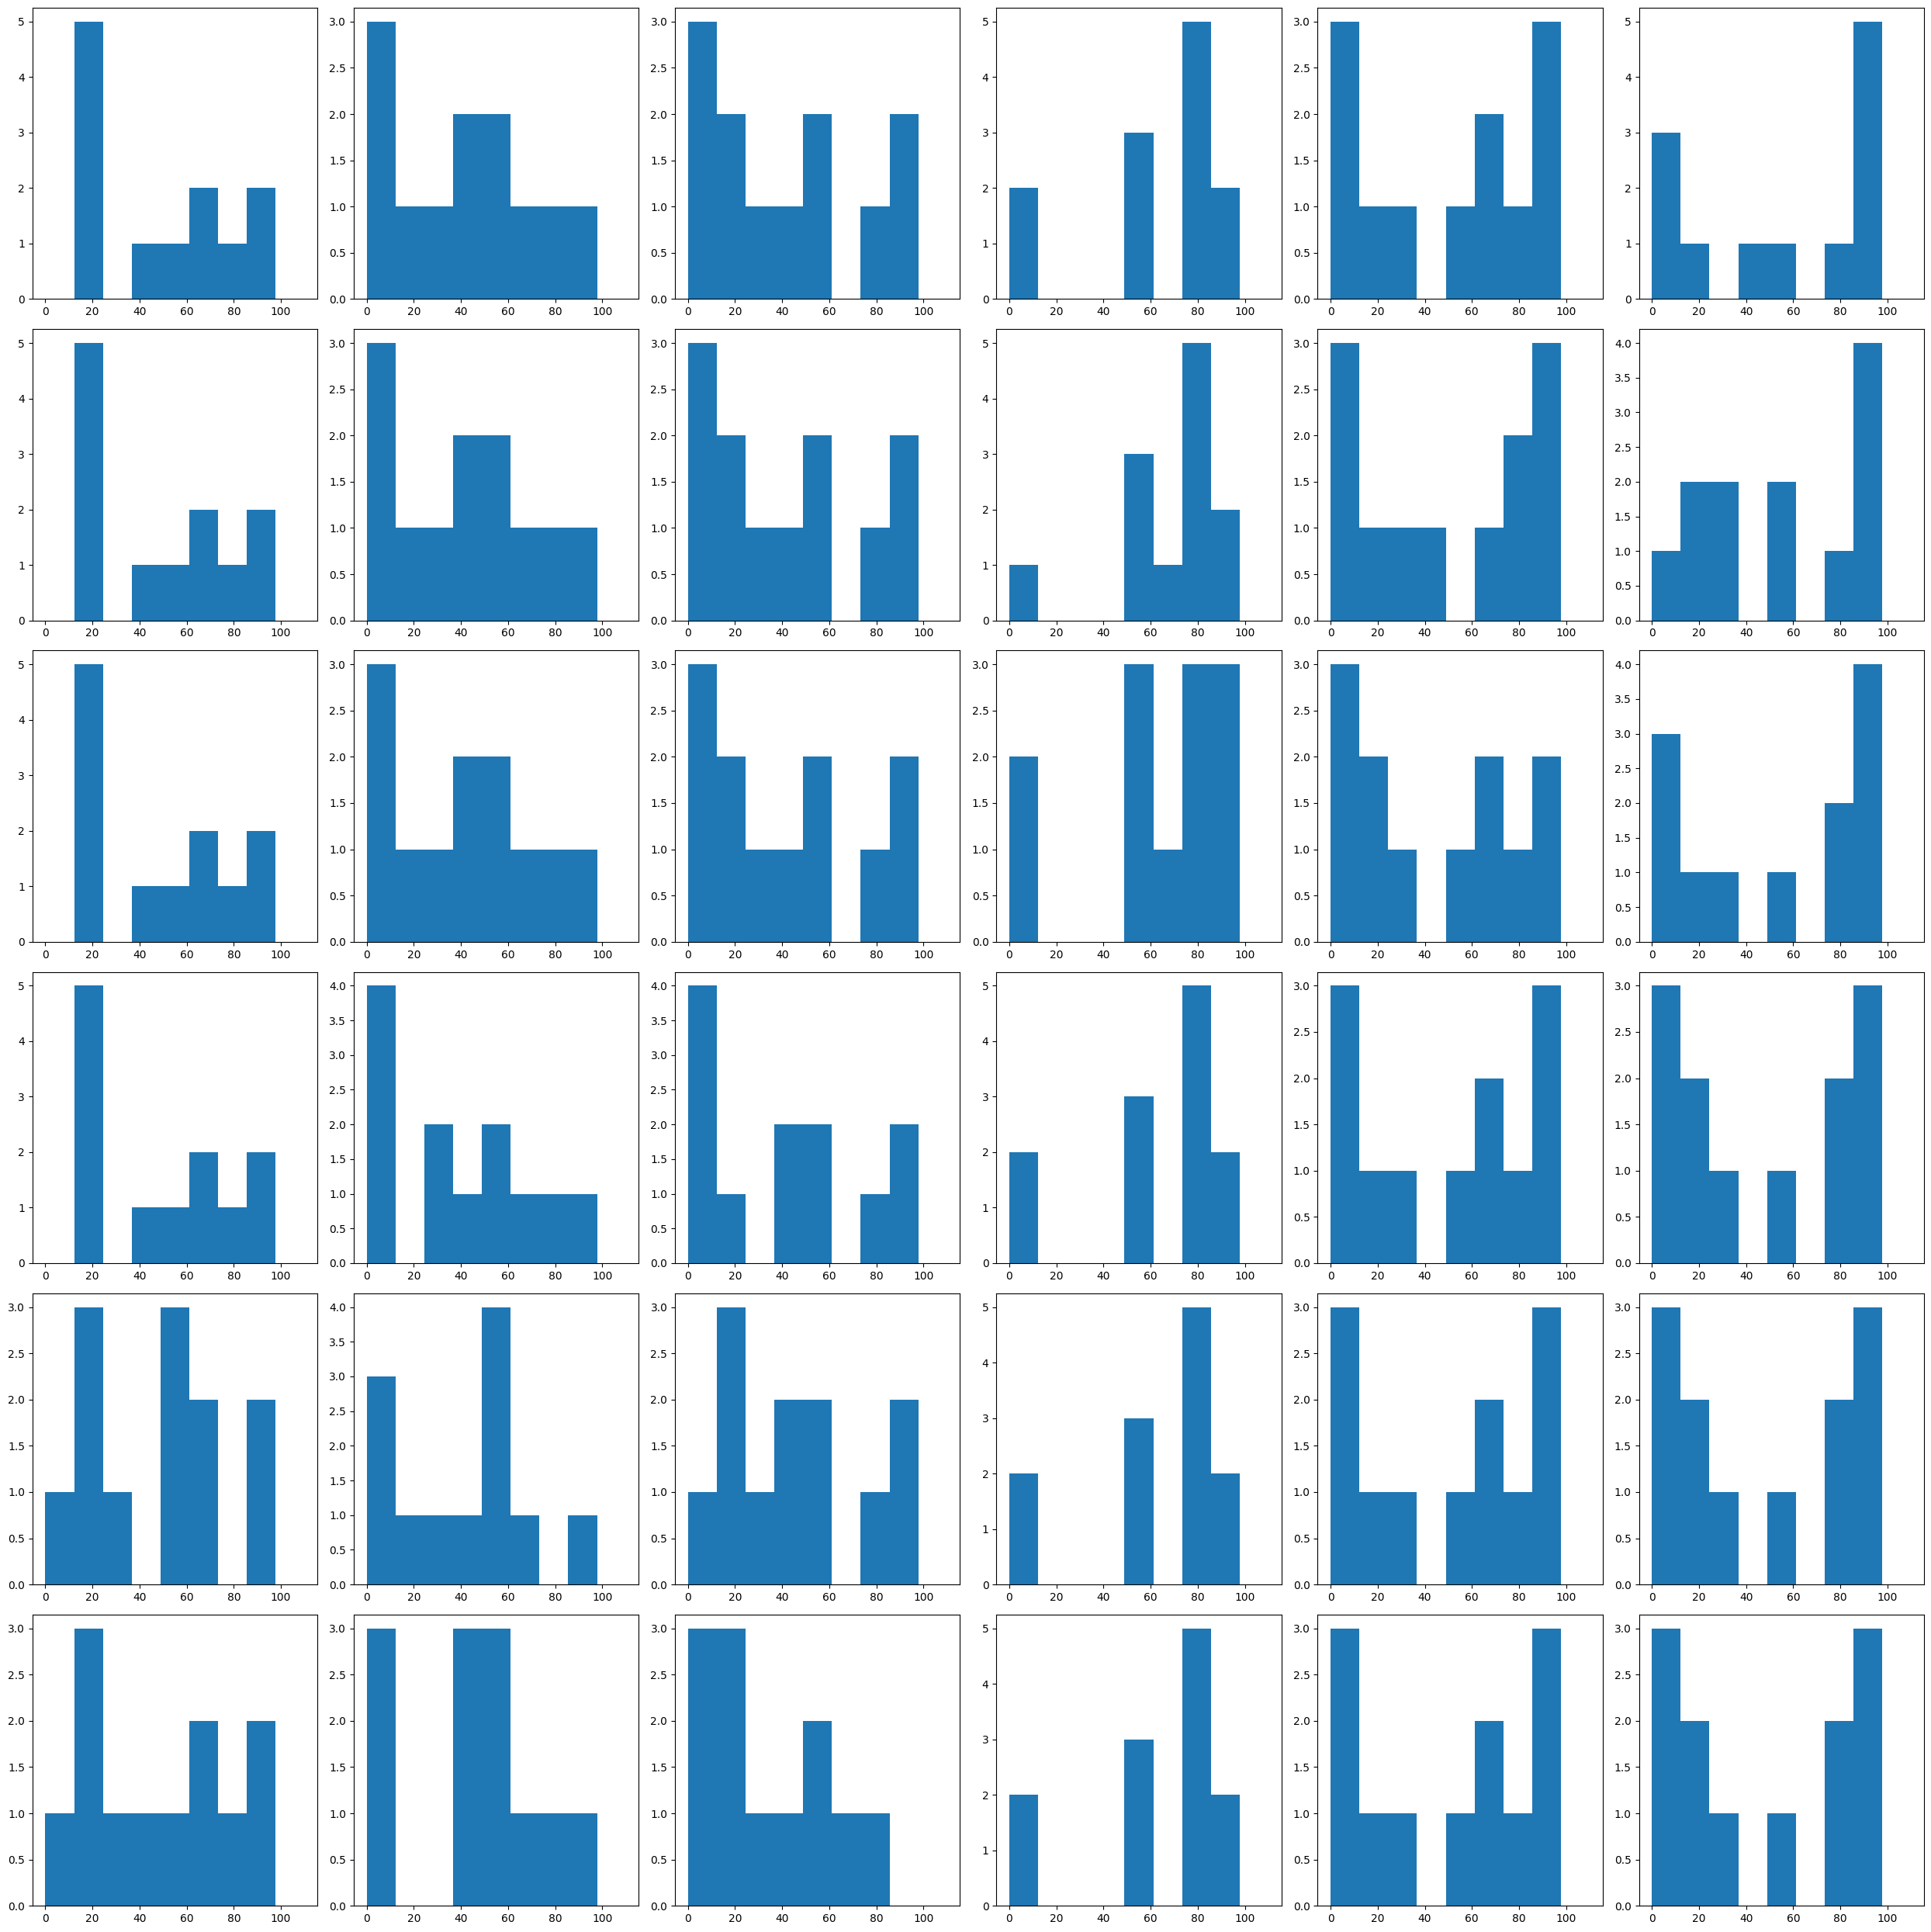

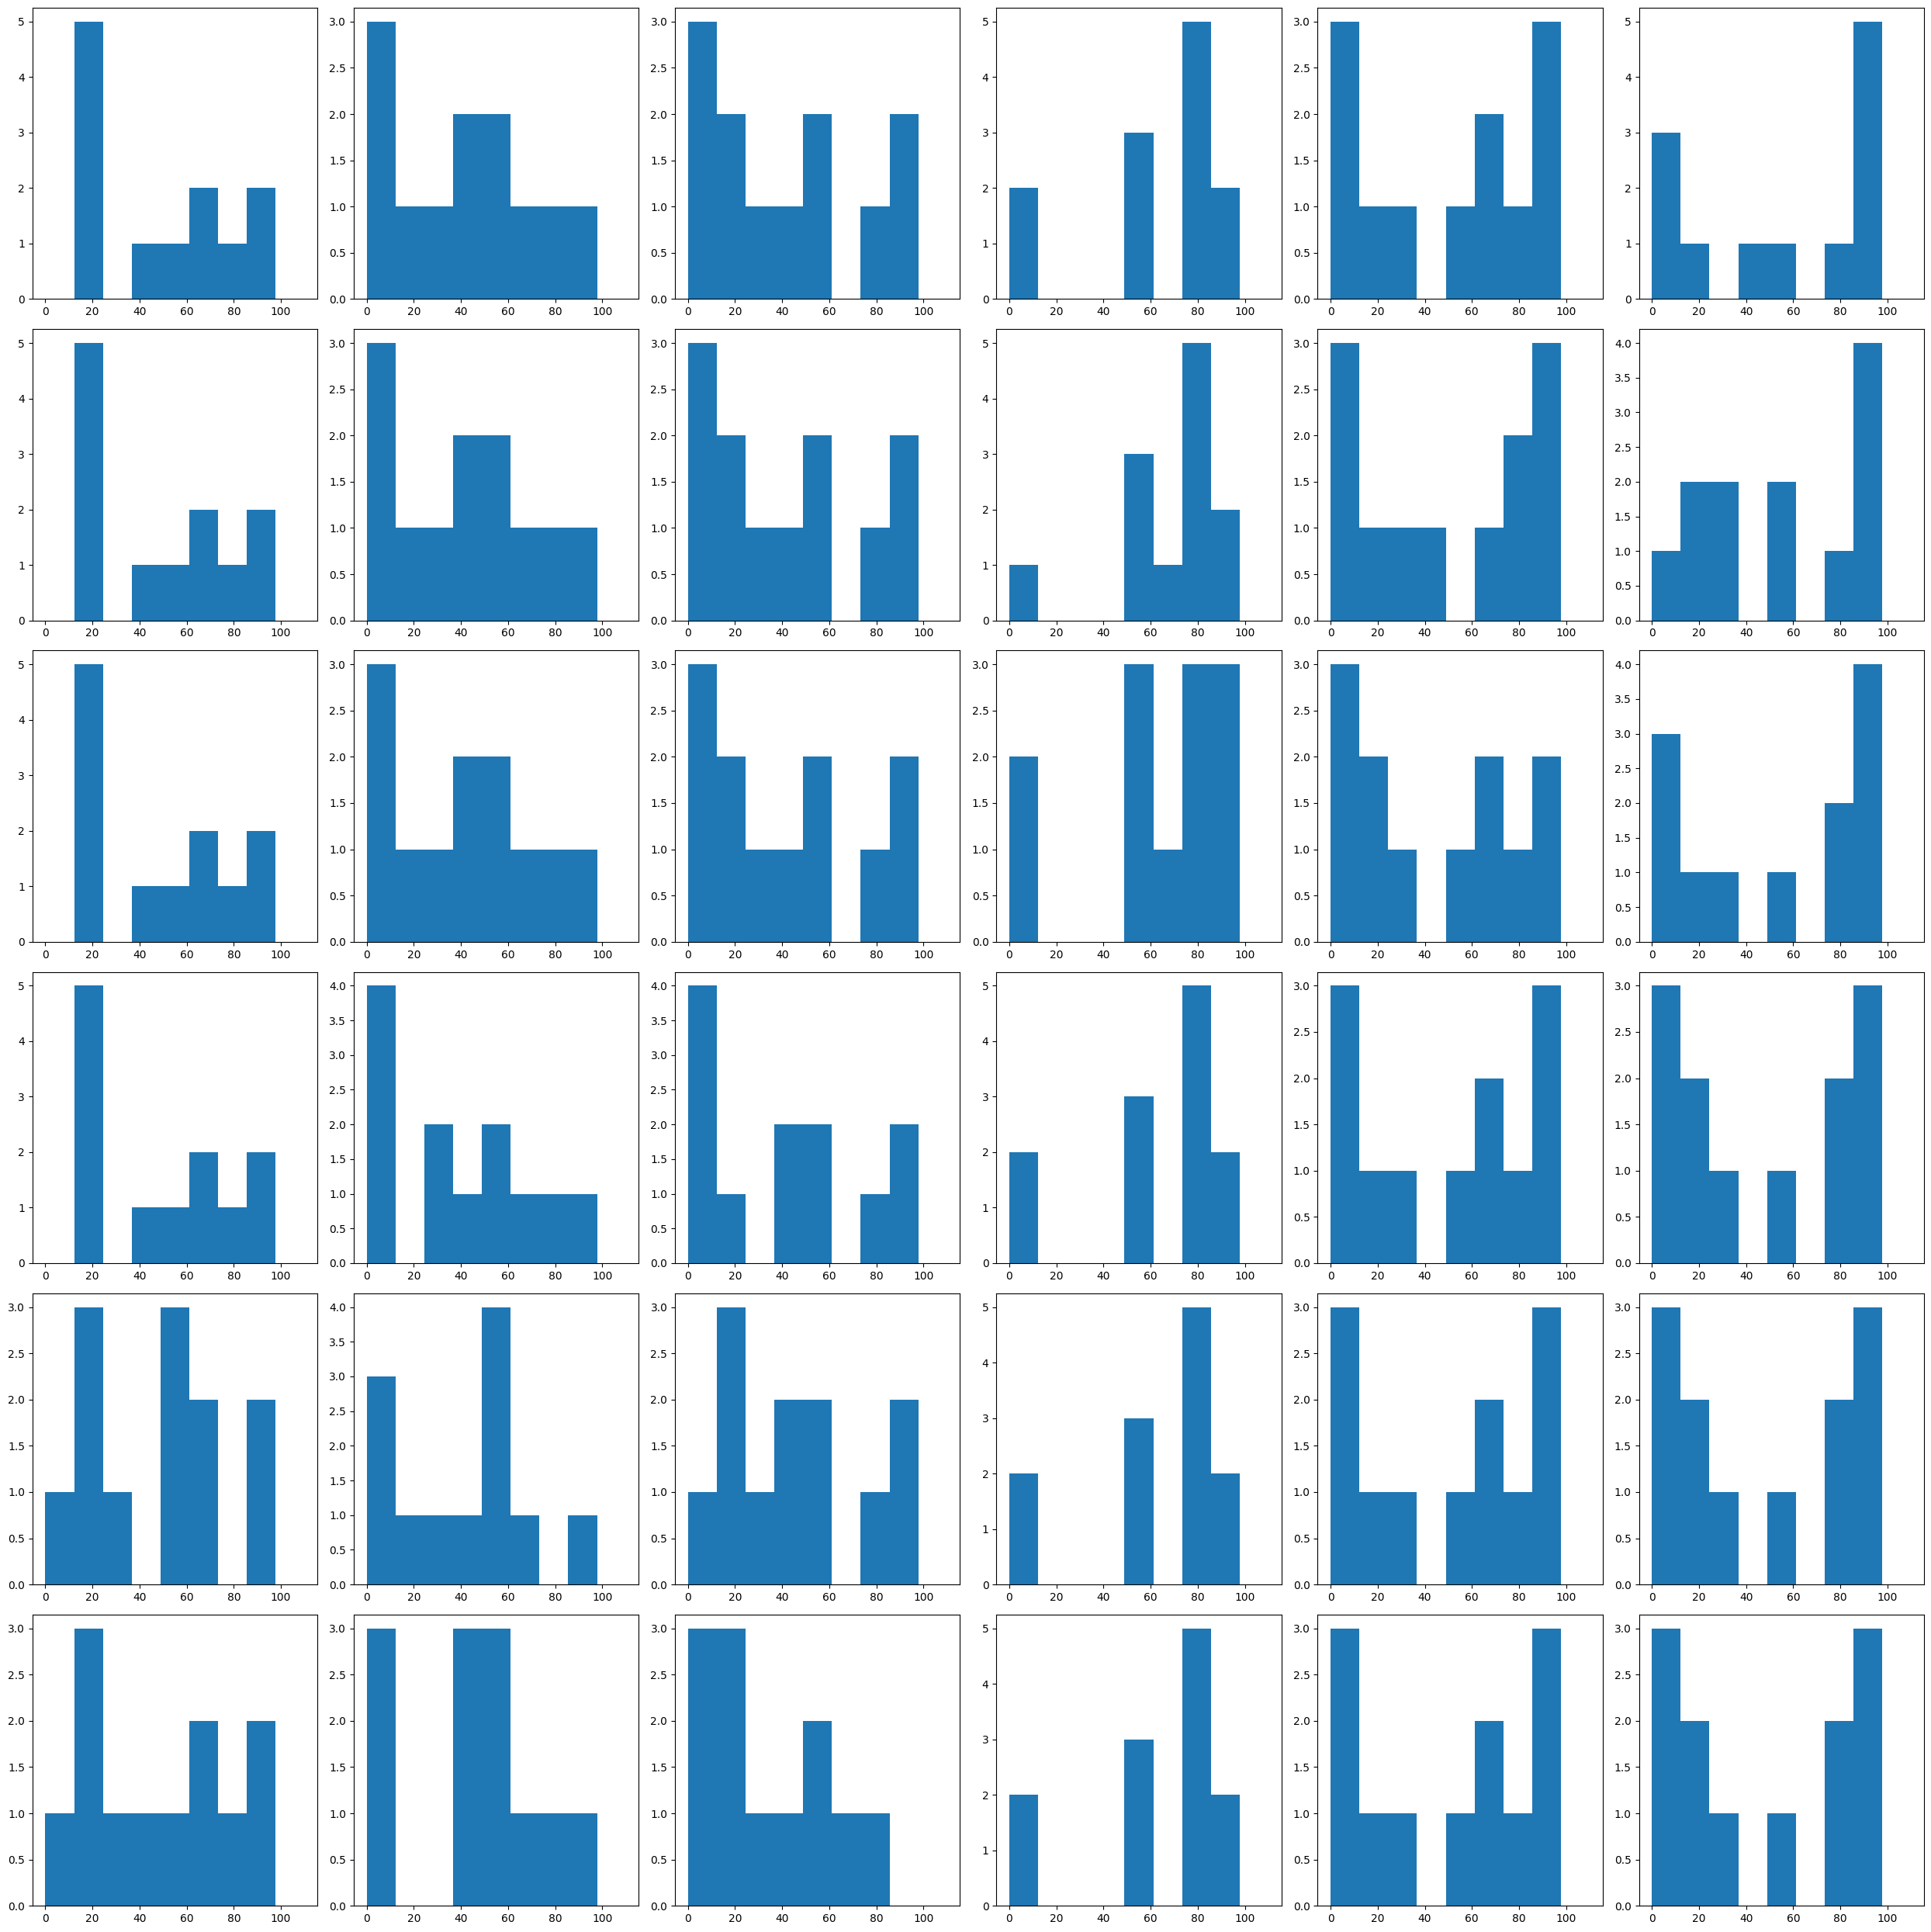

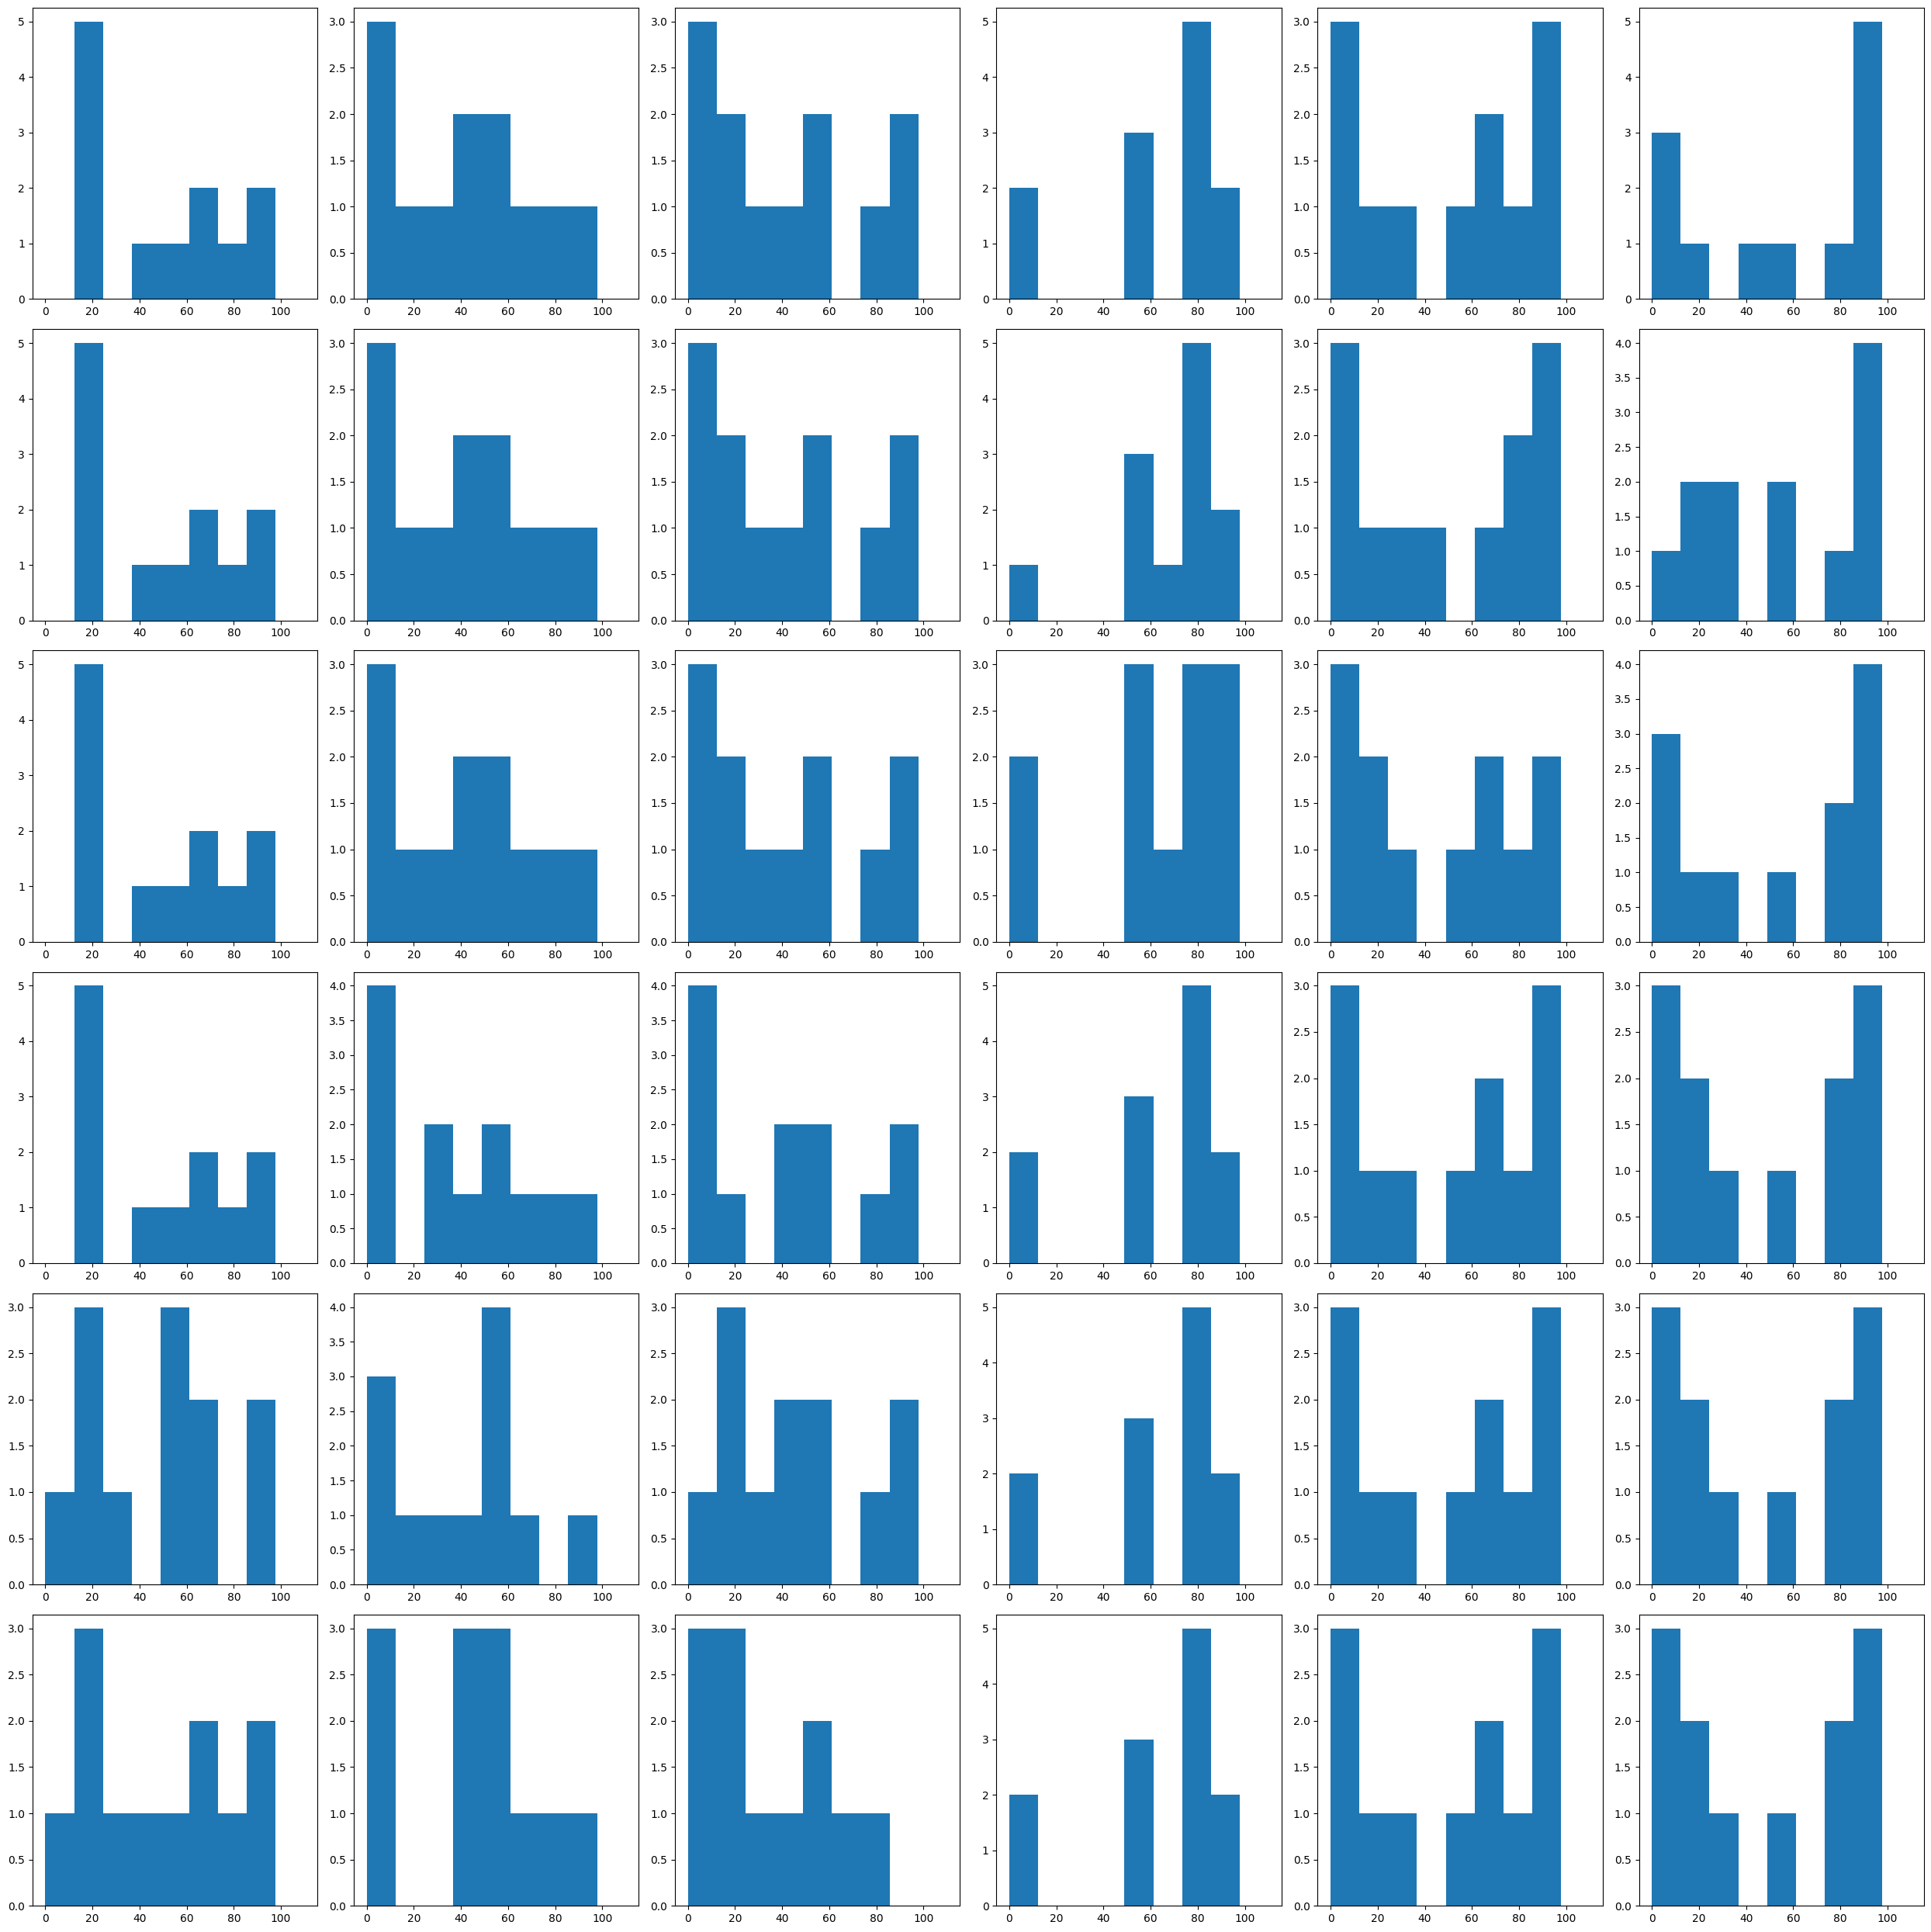

In [15]:
bins=np.linspace(0, 11*time_bin_size*1000,10)        
fig=plt.figure(figsize=(25,25)) 
gs = GridSpec(len(unit_labels), len(unit_labels))
for source in range(len(unit_labels)):
    for target in range(len(unit_labels)):
        ax = fig.add_subplot(gs[source,target])
        conn_lags=[]
        for cond in conditions:
            for x in optimal_lags[cond]:
                conn_lags.append(x[(source,target)][0]*time_bin_size*1000)
        plt.hist(conn_lags,bins)
plt.tight_layout()

for cond in conditions:
    fig=plt.figure(figsize=(25,25)) 
    gs = GridSpec(len(unit_labels), len(unit_labels))
    for source in range(len(unit_labels)):
        for target in range(len(unit_labels)):
            ax = fig.add_subplot(gs[source,target])
            plt.hist([x[(source,target)][0]*time_bin_size*1000 for x in optimal_lags[cond]],bins)
    plt.tight_layout()

In [16]:
n_permutations = 1000
alpha = 0.05
n_units = gc_matrices[conditions[0]][0].shape[0]

In [17]:
diff_gc_matrices = []  # For observed differences across subjects
permuted_diff_gc_matrices = []  # For permuted differences
n_cond_permutations = 100000
# Observed differences
for s_idx in range(n_subjects):
    observed_diff = signed_gc_matrices['SS'][s_idx] - signed_gc_matrices['FS'][s_idx]
    diff_gc_matrices.append(observed_diff)
diff_gc_matrices = np.array(diff_gc_matrices)  # Shape: (n_subjects, neurons, neurons)

# Permutation testing
for perm_idx in range(n_cond_permutations):
    permuted_diffs = np.zeros((n_subjects, n_units, n_units))
    for s_idx in range(n_subjects):
        signs = np.random.choice([-1, 1], size=(n_units, n_units))
        diffs = signed_gc_matrices['SS'][s_idx] - signed_gc_matrices['FS'][s_idx]
        permuted_diffs[s_idx,:,:] = diffs * signs  # Element-wise sign flip
    # Average across subjects for this permutation
    permuted_diff_gc_matrices.append(np.mean(permuted_diffs, axis=0))
permuted_diff_gc_matrices = np.array(permuted_diff_gc_matrices)  # Shape: (n_permutations, neurons, neurons)

# p-values
p_values_diff = np.zeros((n_units, n_units))
region_map = ['-'.join(label.split('-')[:-1]) for label in unit_labels]  # Keeps STN_L, STN_R distinct
for i in range(n_units):
    for j in range(n_units):
        if region_map[i] != region_map[j]:  # Exclude within-region comparisons
            observed_value = np.mean(diff_gc_matrices[:, i, j])  # Average observed difference
            null_distribution = permuted_diff_gc_matrices[:, i, j]
            # two-tailed p-value
            p_values_diff[i, j] = (np.sum(np.abs(null_distribution) >= np.abs(observed_value)) + 1) / (n_cond_permutations + 1)
        else:
            p_values_diff[i, j] = 1

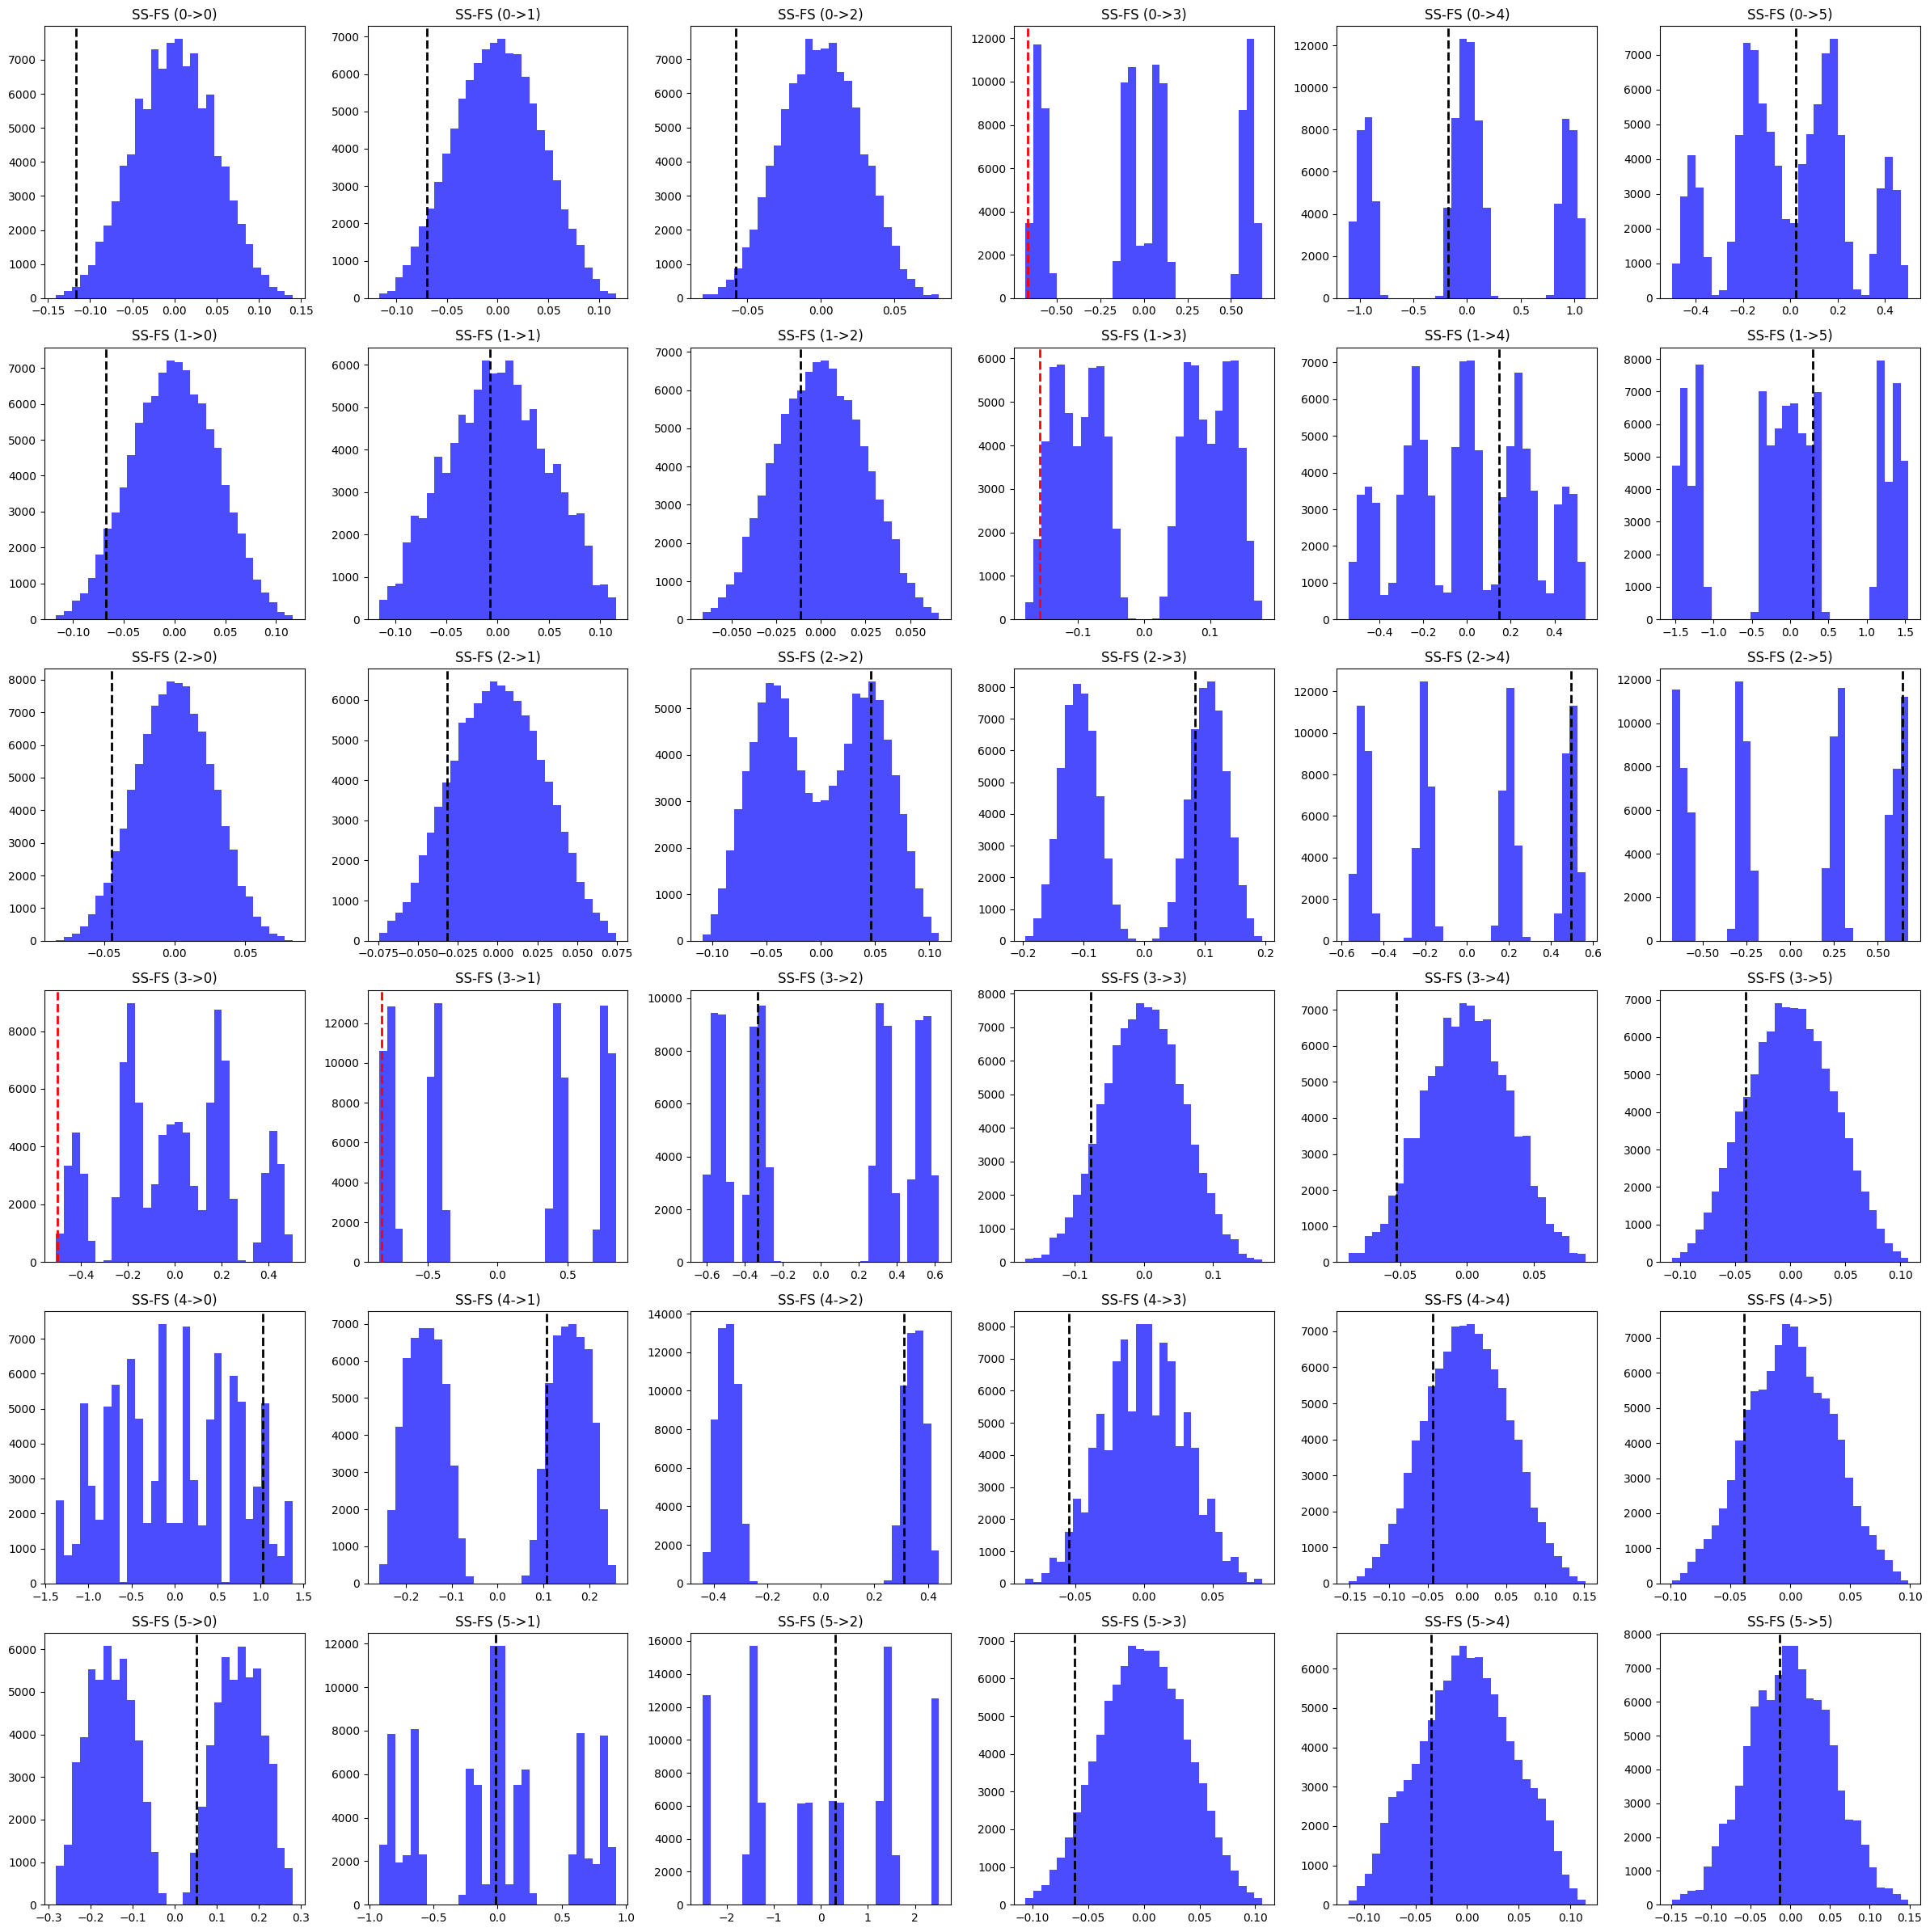

In [18]:
fig = plt.figure(figsize=(24, 24))
gs = GridSpec(n_units, n_units)
for i in range(n_units):
    for j in range(n_units):
        ax = fig.add_subplot(gs[i, j])
        try:
            null_distribution = permuted_diff_gc_matrices[:, i, j]
            observed_value = np.mean(diff_gc_matrices[:, i, j])
            plt.hist(null_distribution, bins=30, alpha=0.7, color='blue', label='Permuted Diff')
            plt.axvline(x=observed_value,
                        color='red' if p_values_diff[i, j] < 0.05 else 'black',
                        linestyle='dashed',
                        linewidth=2)
            plt.title(f"SS-FS ({i}->{j})")
        except:
            pass
plt.tight_layout()

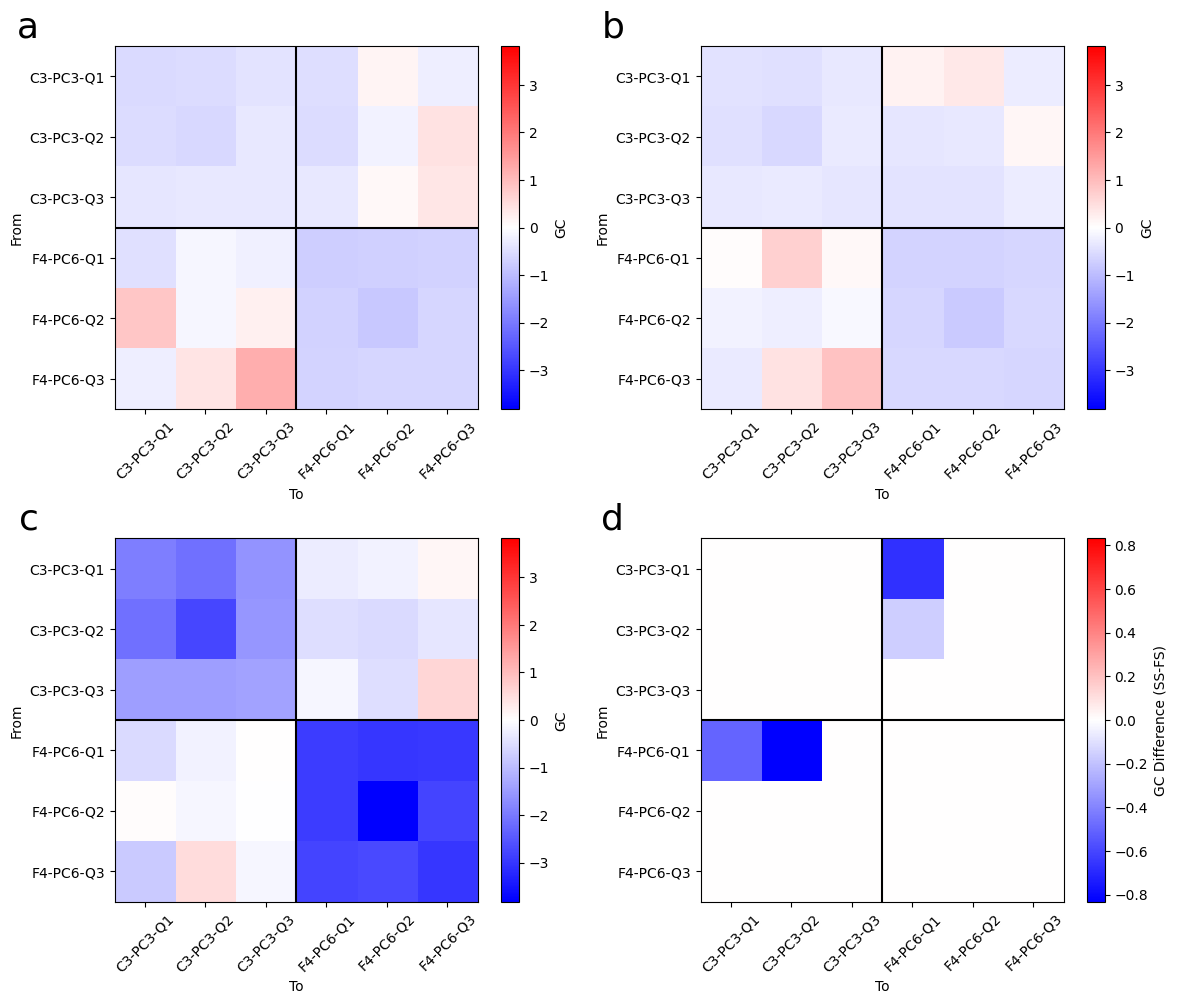

In [19]:
fig = plt.figure(figsize=(12, 10))
gs = GridSpec(2, 2)
# Calculate a dynamic clim based on all conditions
all_gc_values = []
for cond in signed_gc_matrices:
    significant_gc_matrix = np.mean(np.array(signed_gc_matrices[cond]), axis=0)
    # significant_gc_matrix[one_samp_p_values[cond] >= 0.05] = 0
    all_gc_values.extend(significant_gc_matrix.flatten())
common_clim = [-max(abs(np.min(all_gc_values)), np.max(all_gc_values)), max(abs(np.min(all_gc_values)), np.max(all_gc_values))]

ax = fig.add_subplot(gs[0, 0])
significant_gc_matrix = np.mean(np.array(signed_gc_matrices['SS']), axis=0)
# significant_gc_matrix[one_samp_p_values['SS'] >= 0.05] = 0
# Visualize results
im = ax.imshow(significant_gc_matrix, cmap='bwr', interpolation='none', clim=common_clim)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(n_units))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(n_units))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color='k')
plt.axhline(2.5,color='k')
plt.colorbar(im, label='GC')
add_subplot_label(ax, 'a', y=1.1)


ax = fig.add_subplot(gs[0, 1])
significant_gc_matrix = np.mean(np.array(signed_gc_matrices['FS']), axis=0)
# significant_gc_matrix[one_samp_p_values['FS'] >= 0.05] = 0
# Visualize results
im = ax.imshow(significant_gc_matrix, cmap='bwr', interpolation='none', clim=common_clim)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(n_units))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(n_units))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color='k')
plt.axhline(2.5,color='k')
plt.colorbar(im, label='GC')
add_subplot_label(ax, 'b', y=1.1)

ax = fig.add_subplot(gs[1, 0])
significant_gc_matrix = np.mean(np.array(signed_gc_matrices['GO']), axis=0)
# significant_gc_matrix[one_samp_p_values['GO'] >= 0.05] = 0
# Visualize results
im = ax.imshow(significant_gc_matrix, cmap='bwr', interpolation='none', clim=common_clim)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(n_units))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(n_units))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color='k')
plt.axhline(2.5,color='k')
plt.colorbar(im, label='GC')
add_subplot_label(ax, 'c', y=1.1)
    
    
# Plot the GC difference
ax = fig.add_subplot(gs[1, 1])
significant_diff_gc_matrix = np.mean(diff_gc_matrices, axis=0)
significant_diff_gc_matrix[p_values_diff >= 0.05] = 0
# Dynamic clim based on the difference matrix
maxabs = np.max(np.abs(significant_diff_gc_matrix))
im = ax.imshow(significant_diff_gc_matrix, cmap='bwr', interpolation='none', clim=[-maxabs, maxabs])
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(len(unit_labels)))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(len(unit_labels)))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color='k')
plt.axhline(2.5,color='k')
plt.colorbar(im, label='GC Difference (SS-FS)')
add_subplot_label(ax, 'd', y=1.1)
plt.tight_layout()

In [20]:
np.savez(
    '/home/qmoreau/schmidt_data/output/connectivity_t2_c3pc3_f4pc6.npz',
    unit_labels=unit_labels,
    optimal_lags=optimal_lags,
    gc_matrices=gc_matrices,
    signed_gc_matrices=signed_gc_matrices,
    diff_gc_matrices=diff_gc_matrices,
    p_values_diff=p_values_diff
)